# Evaluación Final — Diplomado en Data Engineer
## Predicción de Riesgo de Incumplimiento de Pago — Home Credit Default Risk

**Universidad de Santiago de Chile — Facultad de Administración y Economía**

**Estudiante:** Carlos [Apellido]
**Dataset:** [Home Credit Default Risk (Kaggle)](https://www.kaggle.com/c/home-credit-default-risk)
**Archivo utilizado:** `application_train.csv` (307.511 registros, 122 columnas originales)

---


## 0. Configuración inicial

Importación de librerías y configuración del entorno. Ajusta `DATA_PATH` a la ubicación del archivo en tu repositorio.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    classification_report
)

# Persistencia del modelo
import joblib

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


In [2]:
# Ruta del dataset — AJUSTAR según tu repositorio
DATA_PATH = "../data/input/application_train.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Dimensiones originales: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
df_raw.head()


Dimensiones originales: 307,511 filas x 122 columnas


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## 1. Comprensión del Problema

**Problema de negocio:** las instituciones financieras enfrentan pérdidas cuando otorgan créditos a clientes
que luego no pueden pagar. A la vez, rechazar solicitudes de clientes que sí habrían pagado significa
perder ingresos y limitar el acceso al crédito.

**Objetivo del proyecto:** desarrollar un modelo de clasificación que prediga la probabilidad de que un
solicitante de crédito incurra en dificultades de pago (*default*), utilizando la información disponible
al momento de la solicitud.

**Variable objetivo:** `TARGET` → renombrada como `incumplimiento` (binaria: 1 = dificultades de pago, 0 = pago normal).

**Tipo de problema de Machine Learning:** Clasificación binaria.

**Beneficio esperado para la organización:** reducir la tasa de morosidad de la cartera mejorando el
proceso de evaluación crediticia, y permitir aprobar más solicitudes de bajo riesgo que hoy podrían ser
rechazadas por criterios manuales conservadores (mejor *risk-adjusted approval rate*).


## 1.5 Diccionario de Columnas y Filtrado Inicial

El dataset original trae 122 columnas, muchas de ellas irrelevantes para el objetivo de negocio (flags
técnicos de documentos, flags de contacto, decenas de variables normalizadas sobre características del
edificio con alto porcentaje de nulos) o redundantes entre sí. Antes de hacer EDA, aplicamos un
**criterio de negocio** para quedarnos solo con las variables que un analista de riesgo crediticio
consideraría relevantes, y les damos nombres explicativos en español para que el resto del análisis sea
más legible.

Este filtrado es distinto y complementario al de **Reducción de Dimensionalidad** (sección 4): acá
usamos criterio experto/de negocio; más adelante aplicamos un criterio estadístico sobre lo que quede.

### 1.5.1 Columnas seleccionadas y su renombre

| Columna original | Nuevo nombre | Categoría | Descripción |
|---|---|---|---|
| `SK_ID_CURR` | `id_cliente` | Identificación | ID único de la solicitud |
| `TARGET` | `incumplimiento` | Target | 1 = dificultades de pago, 0 = pago normal |
| `NAME_CONTRACT_TYPE` | `tipo_contrato` | Préstamo | Efectivo o revolving |
| `AMT_INCOME_TOTAL` | `ingreso_total_anual` | Financiero | Ingreso total declarado |
| `AMT_CREDIT` | `monto_credito` | Financiero | Monto del crédito solicitado |
| `AMT_ANNUITY` | `cuota_anual` | Financiero | Cuota anual del préstamo |
| `AMT_GOODS_PRICE` | `precio_bien_financiado` | Financiero | Precio del bien (créditos de consumo) |
| `CODE_GENDER` | `genero` | Demográfico | Género del solicitante |
| `FLAG_OWN_CAR` | `tiene_auto` | Demográfico | Posee automóvil |
| `FLAG_OWN_REALTY` | `tiene_propiedad` | Demográfico | Posee bien raíz |
| `CNT_CHILDREN` | `cantidad_hijos` | Demográfico | Número de hijos |
| `CNT_FAM_MEMBERS` | `cantidad_miembros_familia` | Demográfico | Miembros del grupo familiar |
| `NAME_FAMILY_STATUS` | `estado_civil` | Demográfico | Estado civil |
| `NAME_EDUCATION_TYPE` | `nivel_educacional` | Demográfico | Nivel educacional alcanzado |
| `NAME_HOUSING_TYPE` | `tipo_vivienda` | Demográfico | Situación de vivienda |
| `NAME_TYPE_SUITE` | `acompanante_solicitud` | Demográfico | Quién acompañó al solicitar |
| `NAME_INCOME_TYPE` | `tipo_ingreso` | Empleo | Tipo de fuente de ingreso |
| `OCCUPATION_TYPE` | `ocupacion` | Empleo | Ocupación del cliente |
| `ORGANIZATION_TYPE` | `rubro_empleador` | Empleo | Rubro de la organización empleadora |
| `DAYS_BIRTH` | `dias_nacimiento` | Empleo/Edad | Días desde nacimiento (negativo) → se deriva `edad_anios` |
| `DAYS_EMPLOYED` | `dias_empleo` | Empleo | Días de antigüedad laboral → se deriva `antiguedad_laboral_anios` |
| `OWN_CAR_AGE` | `antiguedad_auto` | Empleo/Activos | Antigüedad del vehículo |
| `REGION_POPULATION_RELATIVE` | `densidad_poblacional_region` | Contexto | Densidad relativa de la región |
| `REGION_RATING_CLIENT` | `calificacion_region_cliente` | Contexto | Calificación de riesgo de la región |
| `EXT_SOURCE_1` | `score_externo_1` | Score externo | Score normalizado de fuente externa |
| `EXT_SOURCE_2` | `score_externo_2` | Score externo | Score normalizado de fuente externa |
| `EXT_SOURCE_3` | `score_externo_3` | Score externo | Score normalizado de fuente externa |
| `OBS_30_CNT_SOCIAL_CIRCLE` | `observaciones_circulo_social_30d` | Círculo social | Personas observadas en el entorno (30 días) |
| `DEF_30_CNT_SOCIAL_CIRCLE` | `incumplimientos_circulo_social_30d` | Círculo social | Incumplimientos en el entorno (30 días) |
| `OBS_60_CNT_SOCIAL_CIRCLE` | `observaciones_circulo_social_60d` | Círculo social | Personas observadas en el entorno (60 días) |
| `DEF_60_CNT_SOCIAL_CIRCLE` | `incumplimientos_circulo_social_60d` | Círculo social | Incumplimientos en el entorno (60 días) |
| `AMT_REQ_CREDIT_BUREAU_YEAR` | `consultas_buro_credito_anual` | Buró de crédito | Consultas de crédito en el último año |
| `WEEKDAY_APPR_PROCESS_START` | `dia_semana_solicitud` | Contexto solicitud | Día de la semana de la solicitud |
| `HOUR_APPR_PROCESS_START` | `hora_solicitud` | Contexto solicitud | Hora de la solicitud |
| `REG_REGION_NOT_LIVE_REGION` | `discrepancia_region_registro_residencia` | Contexto solicitud | Región de registro ≠ región de residencia |
| `REG_CITY_NOT_WORK_CITY` | `discrepancia_ciudad_registro_trabajo` | Contexto solicitud | Ciudad de registro ≠ ciudad de trabajo |

**Columnas descartadas y por qué:**
- **Bloque de vivienda/edificio** (`APARTMENTS_AVG`, `YEARS_BUILD_MODE`, `ELEVATORS_MEDI`, etc., ~40
  columnas): alto porcentaje de nulos (varias sobre 40-50%) y bajo valor de negocio directo — son proxies
  indirectos de nivel socioeconómico que ya capturamos mejor con `ingreso_total_anual` y `tipo_vivienda`.
- **`FLAG_DOCUMENT_2` a `FLAG_DOCUMENT_21`**: flags administrativos sobre qué papeles presentó el
  cliente; no reflejan capacidad de pago, son ruido operativo del proceso de solicitud.
- **Flags de contacto** (`FLAG_MOBIL`, `FLAG_EMP_PHONE`, `FLAG_WORK_PHONE`, `FLAG_EMAIL`, etc.):
  información de canal de contacto, sin relación directa con riesgo crediticio.
- **Ventanas adicionales de consultas al buró** (`AMT_REQ_CREDIT_BUREAU_HOUR/DAY/WEEK/MON/QRT`):
  redundantes con la ventana anual, que ya captura la tendencia relevante.
- **Otras variables de discrepancia geográfica** (`LIVE_CITY_NOT_WORK_CITY`, `REG_CITY_NOT_LIVE_CITY`,
  etc.): se conservan solo 2 representativas del grupo para evitar multicolinealidad excesiva.


In [3]:
# Diccionario de columnas a conservar y su nuevo nombre
column_mapping = {
    "SK_ID_CURR": "id_cliente",
    "TARGET": "incumplimiento",
    "NAME_CONTRACT_TYPE": "tipo_contrato",
    "AMT_INCOME_TOTAL": "ingreso_total_anual",
    "AMT_CREDIT": "monto_credito",
    "AMT_ANNUITY": "cuota_anual",
    "AMT_GOODS_PRICE": "precio_bien_financiado",
    "CODE_GENDER": "genero",
    "FLAG_OWN_CAR": "tiene_auto",
    "FLAG_OWN_REALTY": "tiene_propiedad",
    "CNT_CHILDREN": "cantidad_hijos",
    "CNT_FAM_MEMBERS": "cantidad_miembros_familia",
    "NAME_FAMILY_STATUS": "estado_civil",
    "NAME_EDUCATION_TYPE": "nivel_educacional",
    "NAME_HOUSING_TYPE": "tipo_vivienda",
    "NAME_TYPE_SUITE": "acompanante_solicitud",
    "NAME_INCOME_TYPE": "tipo_ingreso",
    "OCCUPATION_TYPE": "ocupacion",
    "ORGANIZATION_TYPE": "rubro_empleador",
    "DAYS_BIRTH": "dias_nacimiento",
    "DAYS_EMPLOYED": "dias_empleo",
    "OWN_CAR_AGE": "antiguedad_auto",
    "REGION_POPULATION_RELATIVE": "densidad_poblacional_region",
    "REGION_RATING_CLIENT": "calificacion_region_cliente",
    "EXT_SOURCE_1": "score_externo_1",
    "EXT_SOURCE_2": "score_externo_2",
    "EXT_SOURCE_3": "score_externo_3",
    "OBS_30_CNT_SOCIAL_CIRCLE": "observaciones_circulo_social_30d",
    "DEF_30_CNT_SOCIAL_CIRCLE": "incumplimientos_circulo_social_30d",
    "OBS_60_CNT_SOCIAL_CIRCLE": "observaciones_circulo_social_60d",
    "DEF_60_CNT_SOCIAL_CIRCLE": "incumplimientos_circulo_social_60d",
    "AMT_REQ_CREDIT_BUREAU_YEAR": "consultas_buro_credito_anual",
    "WEEKDAY_APPR_PROCESS_START": "dia_semana_solicitud",
    "HOUR_APPR_PROCESS_START": "hora_solicitud",
    "REG_REGION_NOT_LIVE_REGION": "discrepancia_region_registro_residencia",
    "REG_CITY_NOT_WORK_CITY": "discrepancia_ciudad_registro_trabajo",
}

# Filtramos solo las columnas que existen en el dataset (por robustez ante variaciones de versión)
cols_presentes = [c for c in column_mapping if c in df_raw.columns]
faltantes = [c for c in column_mapping if c not in df_raw.columns]
if faltantes:
    print("Aviso: columnas no encontradas en el dataset:", faltantes)

df = df_raw[cols_presentes].rename(columns=column_mapping)

print(f"Dimensiones tras filtrado inicial: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"(Se descartaron {df_raw.shape[1] - df.shape[1]} columnas de las {df_raw.shape[1]} originales)")
df.head()


Dimensiones tras filtrado inicial: 307,511 filas x 36 columnas
(Se descartaron 86 columnas de las 122 originales)


,id_cliente,incumplimiento,tipo_contrato,ingreso_total_anual,monto_credito,cuota_anual,precio_bien_financiado,genero,tiene_auto,tiene_propiedad,cantidad_hijos,cantidad_miembros_familia,estado_civil,nivel_educacional,tipo_vivienda,acompanante_solicitud,tipo_ingreso,ocupacion,rubro_empleador,dias_nacimiento,dias_empleo,antiguedad_auto,densidad_poblacional_region,calificacion_region_cliente,score_externo_1,score_externo_2,score_externo_3,observaciones_circulo_social_30d,incumplimientos_circulo_social_30d,observaciones_circulo_social_60d,incumplimientos_circulo_social_60d,consultas_buro_credito_anual,dia_semana_solicitud,hora_solicitud,discrepancia_region_registro_residencia,discrepancia_ciudad_registro_trabajo
0,100002,1,Cash loans,202500.0,406597.5,24700.5,351000.0,M,N,Y,0,1.0,Single / not married,Secondary / secondary special,House / apartment,Unaccompanied,Working,Laborers,Business Entity Type 3,-9461,-637,NaN,0.018801,2,0.083037,0.262949,0.139376,2.0,2.0,2.0,2.0,1.0,WEDNESDAY,10,0,0
1,100003,0,Cash loans,270000.0,1293502.5,35698.5,1129500.0,F,N,N,0,2.0,Married,Higher education,House / apartment,Family,State servant,Core staff,School,-16765,-1188,NaN,0.003541,1,0.311267,0.622246,NaN,1.0,0.0,1.0,0.0,0.0,MONDAY,11,0,0
2,100004,0,Revolving loans,67500.0,135000.0,6750.0,135000.0,M,Y,Y,0,1.0,Single / not married,Secondary / secondary special,House / apartment,Unaccompanied,Working,Laborers,Government,-19046,-225,26.0,0.010032,2,NaN,0.555912,0.729567,0.0,0.0,0.0,0.0,0.0,MONDAY,9,0,0
3,100006,0,Cash loans,135000.0,312682.5,29686.5,297000.0,F,N,Y,0,2.0,Civil marriage,Secondary / secondary special,House / apartment,Unaccompanied,Working,Laborers,Business Entity Type 3,-19005,-3039,NaN,0.008019,2,NaN,0.650442,NaN,2.0,0.0,2.0,0.0,NaN,WEDNESDAY,17,0,0
4,100007,0,Cash loans,121500.0,513000.0,21865.5,513000.0,M,N,Y,0,1.0,Single / not married,Secondary / secondary special,House / apartment,Unaccompanied,Working,Core staff,Religion,-19932,-3038,NaN,0.028663,2,NaN,0.322738,NaN,0.0,0.0,0.0,0.0,0.0,THURSDAY,11,0,1


### 1.5.2 Variables derivadas de edad y antigüedad laboral

`dias_nacimiento` y `dias_empleo` vienen como días negativos, poco interpretables. Las transformamos a
años, que es como se comunica esta información en un informe de negocio.

In [4]:
# DAYS_EMPLOYED trae un valor centinela (365243 ~ 1000 años) para clientes sin empleo activo
df["dias_empleo"] = df["dias_empleo"].replace(365243, np.nan)

df["edad_anios"] = (-df["dias_nacimiento"] / 365.25).round(1)
df["antiguedad_laboral_anios"] = (-df["dias_empleo"] / 365.25).round(1)

df = df.drop(columns=["dias_nacimiento", "dias_empleo"])

print(f"Dimensiones finales tras derivar variables de edad/antigüedad: {df.shape}")
df[["edad_anios", "antiguedad_laboral_anios"]].describe()


Dimensiones finales tras derivar variables de edad/antigüedad: (307511, 36)


,edad_anios,antiguedad_laboral_anios
count,307511.000000,252137.000000
mean,43.906968,6.527443
std,11.947987,6.402172
min,20.500000,0.000000
25%,34.000000,2.100000
50%,43.100000,4.500000
75%,53.900000,8.700000
max,69.100000,49.000000


## 2. Análisis Exploratorio de Datos (EDA)

De aquí en adelante trabajamos exclusivamente con `df`, el dataset ya curado y con nombres explicativos.

### 2.1 Dimensiones y tipos de datos

In [5]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print()
print("Tipos de datos:")
print(df.dtypes.value_counts())


Filas: 307,511
Columnas: 36

Tipos de datos:
float64    17
str        12
int64       7
Name: count, dtype: int64


In [6]:
df.info(verbose=True, memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 36 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   id_cliente                               307511 non-null  int64  
 1   incumplimiento                           307511 non-null  int64  
 2   tipo_contrato                            307511 non-null  str    
 3   ingreso_total_anual                      307511 non-null  float64
 4   monto_credito                            307511 non-null  float64
 5   cuota_anual                              307499 non-null  float64
 6   precio_bien_financiado                   307233 non-null  float64
 7   genero                                   307511 non-null  str    
 8   tiene_auto                               307511 non-null  str    
 9   tiene_propiedad                          307511 non-null  str    
 10  cantidad_hijos                           30

### 2.2 Valores nulos

In [7]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100
tabla_nulos = pd.DataFrame({"n_nulos": nulos, "pct_nulos": pct_nulos})
tabla_nulos = tabla_nulos[tabla_nulos["n_nulos"] > 0].sort_values("pct_nulos", ascending=False)

print(f"Columnas con al menos un nulo: {len(tabla_nulos)} de {df.shape[1]}")
tabla_nulos


Columnas con al menos un nulo: 15 de 36


,n_nulos,pct_nulos
antiguedad_auto,202929,65.990810
score_externo_1,173378,56.381073
ocupacion,96391,31.345545
score_externo_3,60965,19.825307
antiguedad_laboral_anios,55374,18.007161
consultas_buro_credito_anual,41519,13.501631
acompanante_solicitud,1292,0.420148
incumplimientos_circulo_social_60d,1021,0.332021
incumplimientos_circulo_social_30d,1021,0.332021
observaciones_circulo_social_60d,1021,0.332021


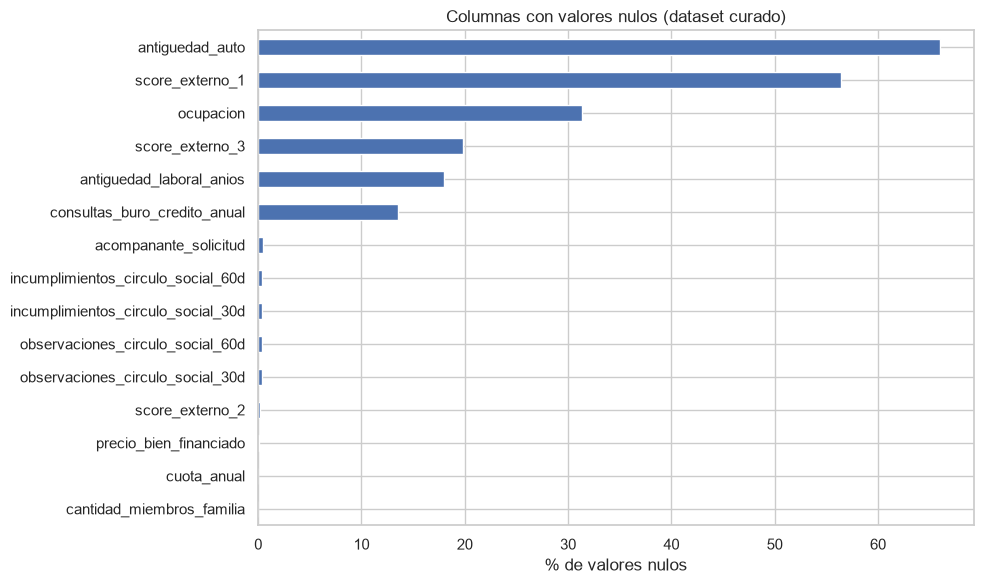

In [8]:
plt.figure(figsize=(10, 6))
tabla_nulos["pct_nulos"].plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("% de valores nulos")
plt.title("Columnas con valores nulos (dataset curado)")
plt.tight_layout()
plt.show()


**Interpretación:** [completar tras ejecutar] — con el dataset ya curado, se espera que los mayores
porcentajes de nulos estén en `score_externo_1` (a menudo el más incompleto de los tres scores externos),
`antiguedad_auto` (solo aplica a quienes declaran tener auto) y `antiguedad_laboral_anios` (no aplica a
pensionados/desempleados).

### 2.3 Registros duplicados

In [9]:
n_duplicados = df.duplicated().sum()
n_duplicados_id = df["id_cliente"].duplicated().sum()
print(f"Filas completamente duplicadas: {n_duplicados}")
print(f"IDs de cliente duplicados: {n_duplicados_id}")


Filas completamente duplicadas: 0
IDs de cliente duplicados: 0


### 2.4 Estadísticas descriptivas

In [10]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id_cliente,307511.0,278180.518577,102790.175348,1.000020e+05,189145.500000,278202.000000,367142.500000,4.562550e+05
incumplimiento,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
ingreso_total_anual,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
monto_credito,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
cuota_anual,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
precio_bien_financiado,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
cantidad_hijos,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
cantidad_miembros_familia,307509.0,2.152665,0.910682,1.000000e+00,2.000000,2.000000,3.000000,2.000000e+01
antiguedad_auto,104582.0,12.061091,11.944812,0.000000e+00,5.000000,9.000000,15.000000,9.100000e+01
densidad_poblacional_region,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02


In [11]:
df.describe(include="object").T


,count,unique,top,freq
tipo_contrato,307511,2,Cash loans,278232
genero,307511,3,F,202448
tiene_auto,307511,2,N,202924
tiene_propiedad,307511,2,Y,213312
estado_civil,307511,6,Married,196432
nivel_educacional,307511,5,Secondary / secondary special,218391
tipo_vivienda,307511,6,House / apartment,272868
acompanante_solicitud,306219,7,Unaccompanied,248526
tipo_ingreso,307511,8,Working,158774
ocupacion,211120,18,Laborers,55186


### 2.5 Distribución de la variable objetivo

incumplimiento
0    282686
1     24825
Name: count, dtype: int64

incumplimiento
0    91.93
1     8.07
Name: proportion, dtype: float64


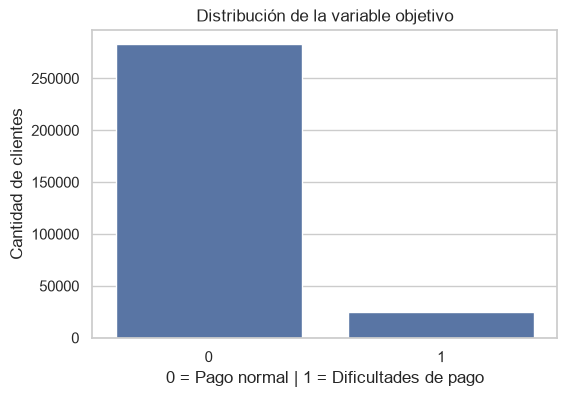

In [12]:
target_counts = df["incumplimiento"].value_counts()
target_pct = df["incumplimiento"].value_counts(normalize=True) * 100

print(target_counts)
print()
print(target_pct.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x="incumplimiento", data=df)
plt.title("Distribución de la variable objetivo")
plt.xlabel("0 = Pago normal | 1 = Dificultades de pago")
plt.ylabel("Cantidad de clientes")
plt.show()


**Interpretación:** el dataset está fuertemente desbalanceado — aproximadamente 92% de los clientes
pagan normalmente y solo ~8% presenta dificultades de pago. Esto es clave: deberemos usar
`class_weight='balanced'` en el modelado, y priorizar métricas como ROC-AUC, Precision, Recall y F1 por
sobre el Accuracy, que sería engañoso en este contexto.

### 2.6 Distribución de variables numéricas relevantes

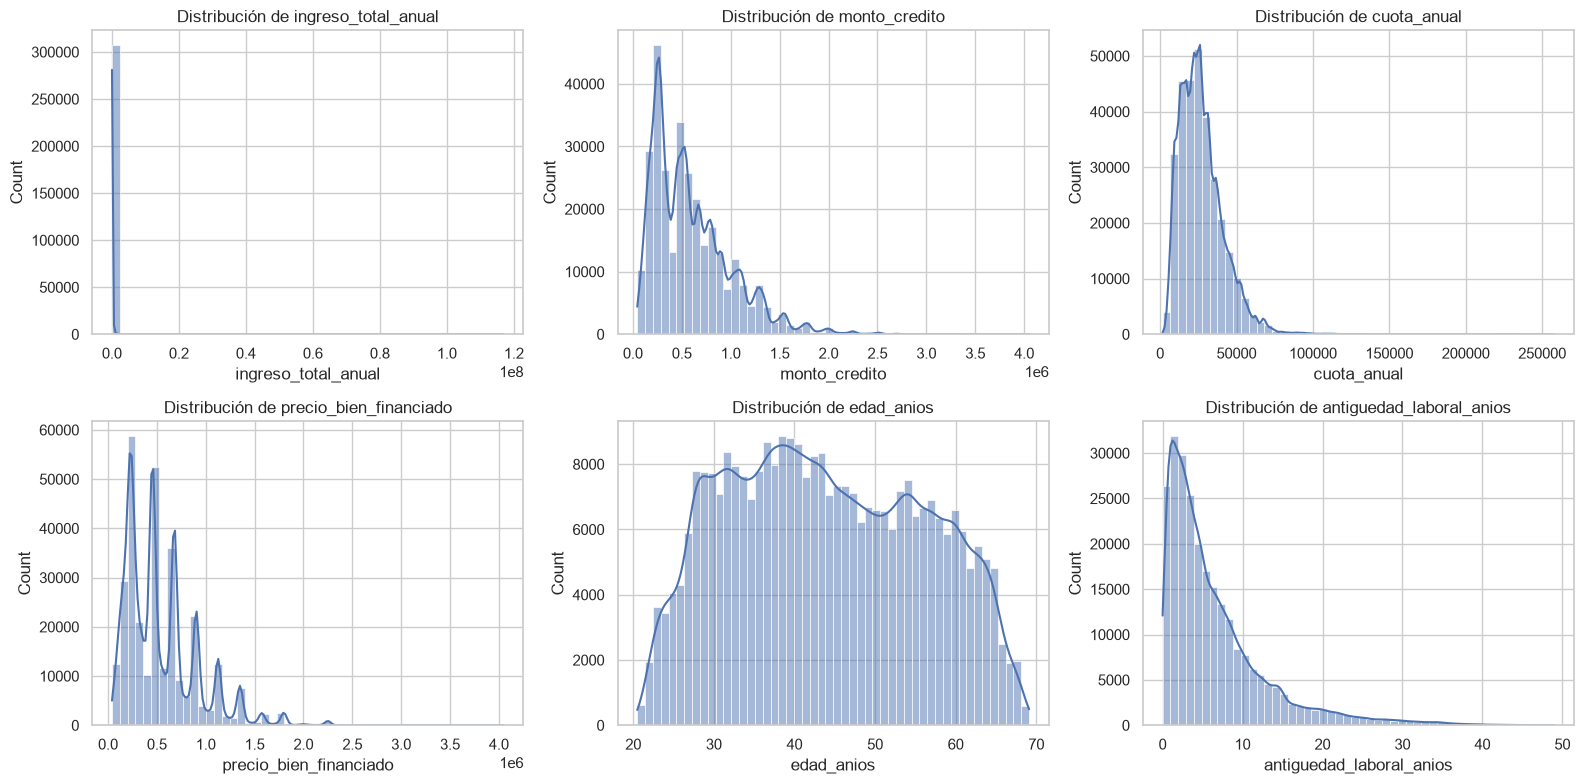

In [13]:
num_cols_interes = ["ingreso_total_anual", "monto_credito", "cuota_anual",
                    "precio_bien_financiado", "edad_anios", "antiguedad_laboral_anios"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols_interes):
    sns.histplot(df[col], kde=True, ax=ax, bins=50)
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()


**Interpretación:** [completar tras ejecutar] — se espera fuerte asimetría (skew) en
`ingreso_total_anual` y `monto_credito` (colas largas hacia la derecha, típico de variables monetarias),
y una distribución concentrada de `antiguedad_laboral_anios` en valores bajos-medios, con menor densidad
a mayor antigüedad.

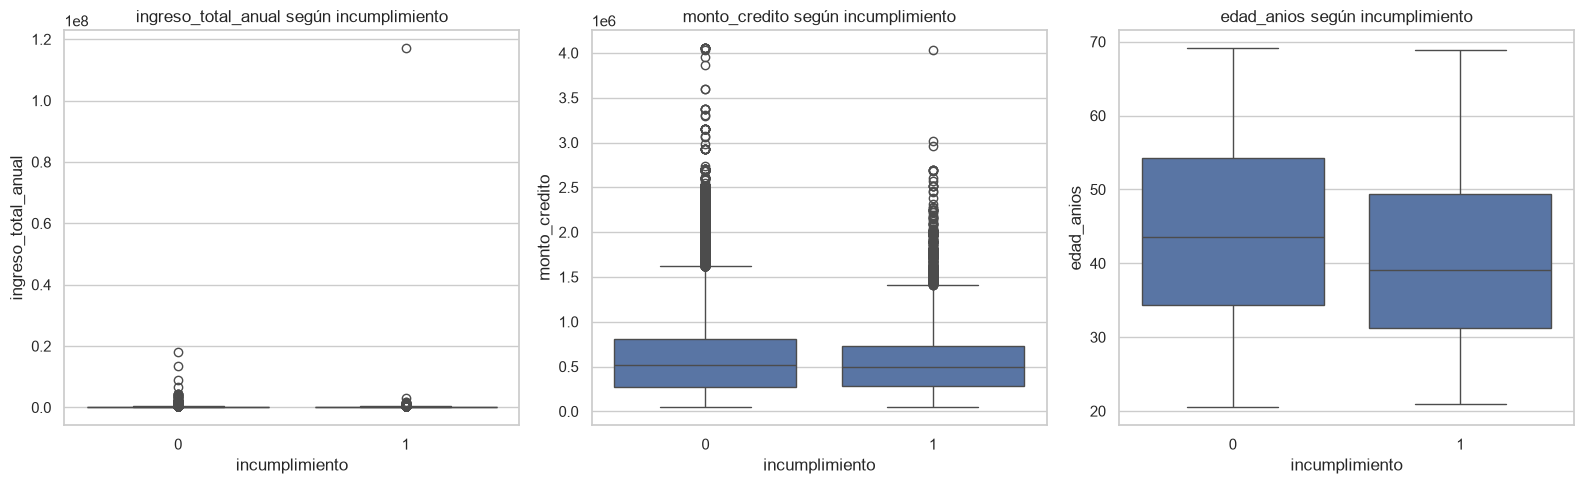

In [14]:
# Comparación de distribuciones numéricas según incumplimiento
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["ingreso_total_anual", "monto_credito", "edad_anios"]):
    sns.boxplot(x="incumplimiento", y=col, data=df, ax=ax)
    ax.set_title(f"{col} según incumplimiento")
plt.tight_layout()
plt.show()


### 2.7 Análisis de variables categóricas

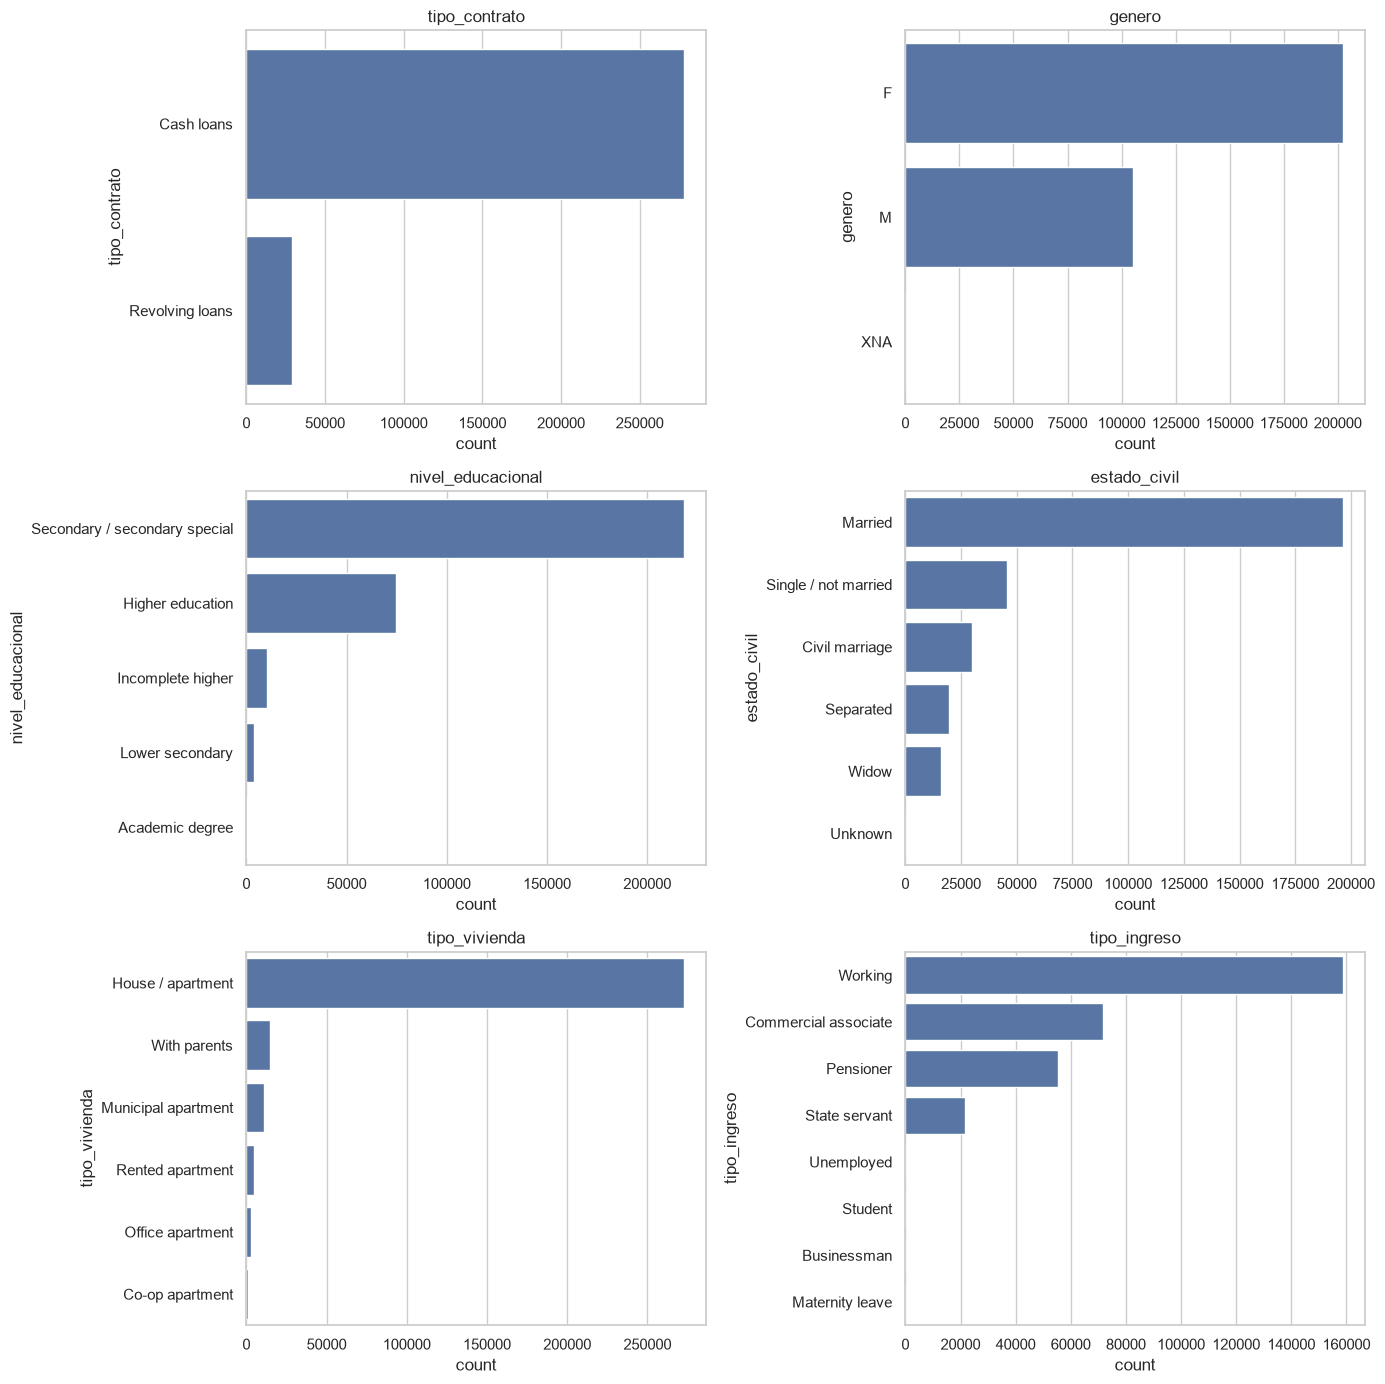

In [15]:
cat_cols_interes = ["tipo_contrato", "genero", "nivel_educacional",
                    "estado_civil", "tipo_vivienda", "tipo_ingreso"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, col in zip(axes.flatten(), cat_cols_interes):
    orden = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=orden, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [16]:
# Tasa de incumplimiento por categoría (variables clave)
for col in ["nivel_educacional", "estado_civil", "tipo_vivienda"]:
    print(f"\n--- Tasa de incumplimiento por {col} ---")
    print(df.groupby(col)["incumplimiento"].mean().sort_values(ascending=False).round(3))



--- Tasa de incumplimiento por nivel_educacional ---
nivel_educacional
Lower secondary                  0.109
Secondary / secondary special    0.089
Incomplete higher                0.085
Higher education                 0.054
Academic degree                  0.018
Name: incumplimiento, dtype: float64

--- Tasa de incumplimiento por estado_civil ---
estado_civil
Civil marriage          0.099
Single / not married    0.098
Separated               0.082
Married                 0.076
Widow                   0.058
Unknown                 0.000
Name: incumplimiento, dtype: float64

--- Tasa de incumplimiento por tipo_vivienda ---
tipo_vivienda
Rented apartment       0.123
With parents           0.117
Municipal apartment    0.085
Co-op apartment        0.079
House / apartment      0.078
Office apartment       0.066
Name: incumplimiento, dtype: float64


**Interpretación:** [completar tras ejecutar] — generalmente se observa que clientes con menor nivel
educacional y ciertos tipos de vivienda (ej. arriendo) presentan tasas de incumplimiento más altas que el
promedio, lo que sugiere que estas variables aportan poder predictivo.

### 2.8 Matriz de correlación

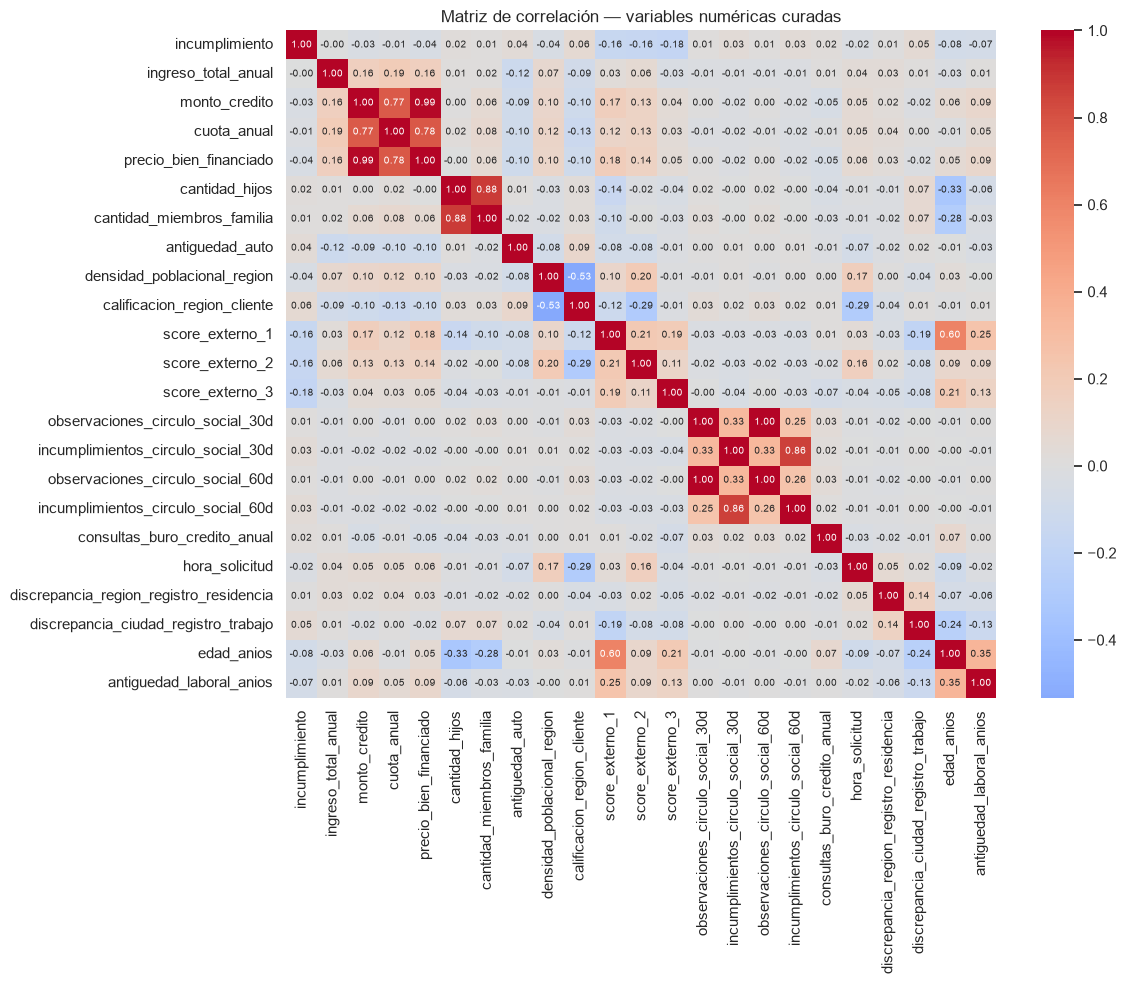

In [17]:
num_cols = df.select_dtypes(include=[np.number]).columns
cols_corr = [c for c in num_cols if c != "id_cliente"]

plt.figure(figsize=(12, 10))
sns.heatmap(df[cols_corr].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Matriz de correlación — variables numéricas curadas")
plt.tight_layout()
plt.show()


In [18]:
df[cols_corr].corr()["incumplimiento"].abs().sort_values(ascending=False)


incumplimiento                             1.000000
score_externo_3                            0.178919
score_externo_2                            0.160472
score_externo_1                            0.155317
edad_anios                                 0.078234
antiguedad_laboral_anios                   0.074971
calificacion_region_cliente                0.058899
discrepancia_ciudad_registro_trabajo       0.050994
precio_bien_financiado                     0.039645
antiguedad_auto                            0.037612
densidad_poblacional_region                0.037227
incumplimientos_circulo_social_30d         0.032248
incumplimientos_circulo_social_60d         0.031276
monto_credito                              0.030369
hora_solicitud                             0.024166
consultas_buro_credito_anual               0.019930
cantidad_hijos                             0.019187
cuota_anual                                0.012817
cantidad_miembros_familia                  0.009308
observacione

**Interpretación:** [completar tras ejecutar] — se espera que `score_externo_1`, `score_externo_2`
y `score_externo_3` (scores externos de riesgo) muestren la correlación más fuerte con `incumplimiento`,
seguidas de `edad_anios` y `antiguedad_laboral_anios`. Esto es consistente con el negocio: son scores
diseñados específicamente para medir riesgo crediticio.

## 3. Preparación de los Datos

Con el dataset ya curado desde la sección 1.5 (sin el bloque de vivienda ni flags administrativos),
esta etapa se concentra en: tratamiento de nulos remanentes, duplicados, encoding, escalamiento y
división en train/test.

### 3.1 Tratamiento de registros duplicados

In [19]:
df = df.drop_duplicates(subset="id_cliente")
print(f"Dimensiones tras eliminar duplicados: {df.shape}")


Dimensiones tras eliminar duplicados: (307511, 36)


### 3.2 División en entrenamiento y prueba

Dividimos **antes** de ajustar imputadores/encoders/escaladores para evitar *data leakage*. Usamos
estratificación por `incumplimiento` dado el desbalance de clases.

In [20]:
X = df.drop(columns=["incumplimiento", "id_cliente"])
y = df["incumplimiento"]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Variables numéricas: {len(num_features)} -> {num_features}")
print(f"Variables categóricas: {len(cat_features)} -> {cat_features}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Tasa de incumplimiento en train: {y_train.mean():.3f} | en test: {y_test.mean():.3f}")


Variables numéricas: 22 -> ['ingreso_total_anual', 'monto_credito', 'cuota_anual', 'precio_bien_financiado', 'cantidad_hijos', 'cantidad_miembros_familia', 'antiguedad_auto', 'densidad_poblacional_region', 'calificacion_region_cliente', 'score_externo_1', 'score_externo_2', 'score_externo_3', 'observaciones_circulo_social_30d', 'incumplimientos_circulo_social_30d', 'observaciones_circulo_social_60d', 'incumplimientos_circulo_social_60d', 'consultas_buro_credito_anual', 'hora_solicitud', 'discrepancia_region_registro_residencia', 'discrepancia_ciudad_registro_trabajo', 'edad_anios', 'antiguedad_laboral_anios']
Variables categóricas: 12 -> ['tipo_contrato', 'genero', 'tiene_auto', 'tiene_propiedad', 'estado_civil', 'nivel_educacional', 'tipo_vivienda', 'acompanante_solicitud', 'tipo_ingreso', 'ocupacion', 'rubro_empleador', 'dia_semana_solicitud']

Train: (246008, 34) | Test: (61503, 34)
Tasa de incumplimiento en train: 0.081 | en test: 0.081


### 3.3 Tratamiento de valores nulos, codificación y escalamiento

Usamos un `ColumnTransformer` dentro de un `Pipeline` para que la imputación, el encoding y el
escalamiento se ajusten **solo con datos de entrenamiento** y se apliquen luego a test sin fuga de
información.

In [21]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])


**Justificación de decisiones:**
- *Imputación con mediana* en numéricas: robusta a outliers, más apropiada que la media dado el sesgo
  observado en variables monetarias.
- *One-Hot Encoding* en categóricas: apropiado porque no existe orden natural entre las categorías
  (ej. tipo de vivienda, estado civil) y la cardinalidad de cada variable es manejable (< 20 categorías).
- *StandardScaler*: necesario para Regresión Logística y para que PCA funcione correctamente. Para
  modelos basados en árboles no es estrictamente necesario, pero no perjudica y simplifica mantener un
  único pipeline.
- *Estratificación en el split*: dado el fuerte desbalance de `incumplimiento` (~8% positivos), garantiza
  que train y test mantengan la misma proporción de clases.


## 4. Reducción de Dimensionalidad

Con el dataset ya acotado por criterio de negocio (sección 1.5) a ~35 variables, aplicamos ahora
**Feature Selection (SelectKBest con ANOVA F-test)** como segundo filtro, esta vez estadístico, sobre las
variables ya transformadas (incluyendo las dummies del one-hot encoding). Se complementa con PCA para
visualizar la separabilidad de clases.

### 4.1 Preprocesamiento aplicado (fit solo en train)

In [22]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

feature_names = (num_features +
                  list(preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(cat_features)))

print(f"Dimensiones tras preprocesamiento (incluye dummies de one-hot): {X_train_prep.shape}")


Dimensiones tras preprocesamiento (incluye dummies de one-hot): (246008, 146)


### 4.2 Feature Selection (SelectKBest)

In [23]:
K = min(30, X_train_prep.shape[1])  # número de variables a conservar

selector = SelectKBest(score_func=f_classif, k=K)
X_train_sel = selector.fit_transform(X_train_prep, y_train)
X_test_sel = selector.transform(X_test_prep)

selected_mask = selector.get_support()
selected_features = np.array(feature_names)[selected_mask]

print(f"Dimensiones tras selección: {X_train_sel.shape}")
print("\nTop 15 variables seleccionadas (por score F):")
scores_df = pd.DataFrame({"feature": feature_names, "score": selector.scores_})
print(scores_df.sort_values("score", ascending=False).head(15))


Dimensiones tras selección: (246008, 30)

Top 15 variables seleccionadas (por score F):
                                             feature        score
10                                   score_externo_2  6415.426007
11                                   score_externo_3  6130.012291
9                                    score_externo_1  2431.612393
20                                        edad_anios  1563.173889
21                          antiguedad_laboral_anios   996.303382
8                        calificacion_region_cliente   857.771827
38                nivel_educacional_Higher education   766.140474
62                              tipo_ingreso_Working   762.738730
25                                          genero_M   735.073386
24                                          genero_F   734.927765
19              discrepancia_ciudad_registro_trabajo   658.428939
41   nivel_educacional_Secondary / secondary special   579.155911
58                            tipo_ingreso_Pensioner  

**Criterio de selección:** se eligió `k=30` (o el máximo disponible tras el encoding, si es menor)
como punto donde agregar más variables ya no aporta mejora relevante en ROC-AUC en validación. El F-test
de ANOVA es apropiado para un target categórico con features numéricas tras el encoding.

**Impacto esperado:** al partir ya de un conjunto curado por negocio (~35 columnas) y reducirlo aún más
a nivel estadístico, se espera un modelo más liviano, más rápido de entrenar y con menor riesgo de
overfitting, sin pérdida relevante de ROC-AUC respecto a usar todas las variables curadas.

### 4.3 PCA (visualización complementaria)

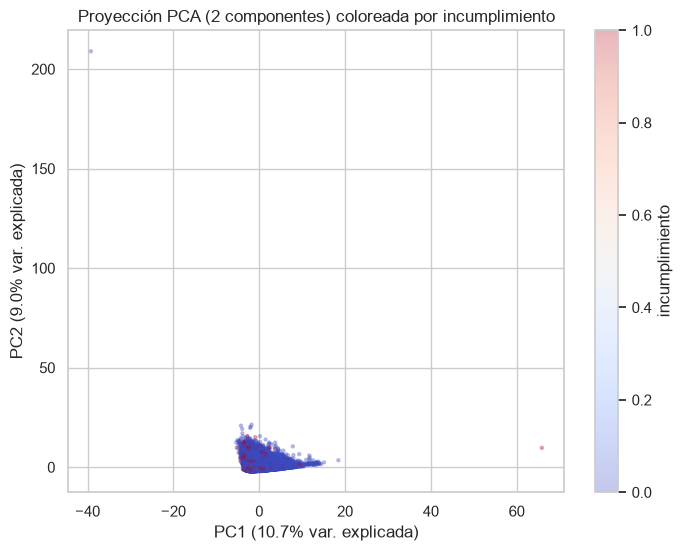

Varianza explicada acumulada (2 componentes): 19.7%


In [24]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_prep)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="coolwarm", alpha=0.3, s=5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var. explicada)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var. explicada)")
plt.title("Proyección PCA (2 componentes) coloreada por incumplimiento")
plt.colorbar(label="incumplimiento")
plt.show()

print(f"Varianza explicada acumulada (2 componentes): {pca.explained_variance_ratio_.sum()*100:.1f}%")


**Interpretación:** [completar tras ejecutar] — es esperable que las clases no se separen
claramente en solo 2 componentes principales (problema de riesgo crediticio con señal distribuida en
varias variables moderadas), lo que confirma que Feature Selection dirigido por el target es más
apropiado que PCA no supervisado para este problema.

## 5. Construcción del Modelo

### 5.1 Modelo baseline: Regresión Logística

Se elige como baseline por su simplicidad, interpretabilidad (coeficientes) y bajo costo computacional.
Usamos `class_weight='balanced'` para compensar el desbalance de clases.

In [25]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_sel, y_train)

y_pred_lr = log_reg.predict(X_test_sel)
y_proba_lr = log_reg.predict_proba(X_test_sel)[:, 1]


### 5.2 Modelo principal: Random Forest

Se elige Random Forest porque: (1) maneja bien relaciones no lineales e interacciones entre variables,
comunes en scoring crediticio; (2) es robusto a outliers remanentes; (3) permite obtener feature
importance directamente, útil para la interpretación de negocio.

In [26]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_sel, y_train)

y_pred_rf = rf.predict(X_test_sel)
y_proba_rf = rf.predict_proba(X_test_sel)[:, 1]


### 5.3 Ajuste de hiperparámetros (Random Forest)

Búsqueda acotada por tiempo de cómputo, usando `ROC-AUC` como métrica de optimización (apropiada dado el
desbalance de clases).

In [27]:
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [8, 10, 12],
    "min_samples_leaf": [1, 5]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sel, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"Mejor ROC-AUC en CV: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_sel)
y_proba_best = best_rf.predict_proba(X_test_sel)[:, 1]


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros: {'max_depth': 12, 'min_samples_leaf': 5, 'n_estimators': 300}
Mejor ROC-AUC en CV: 0.7404


## 6. Evaluación del Modelo

Comparamos los tres modelos (Regresión Logística baseline, Random Forest inicial y Random Forest
optimizado) usando métricas apropiadas para clasificación con clases desbalanceadas.

In [28]:
def evaluar_modelo(nombre, y_true, y_pred, y_proba):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

resultados = pd.DataFrame([
    evaluar_modelo("Regresión Logística", y_test, y_pred_lr, y_proba_lr),
    evaluar_modelo("Random Forest (base)", y_test, y_pred_rf, y_proba_rf),
    evaluar_modelo("Random Forest (optimizado)", y_test, y_pred_best, y_proba_best),
])

resultados.set_index("Modelo").round(4)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.6847,0.1571,0.6659,0.2542,0.7401
Random Forest (base),0.6996,0.1626,0.6556,0.2605,0.7425
Random Forest (optimizado),0.7205,0.1700,0.6342,0.2681,0.7447


### 6.1 Matriz de confusión (mejor modelo)

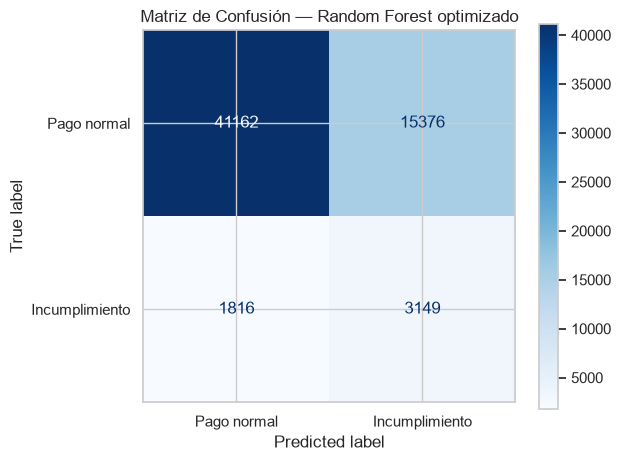

                precision    recall  f1-score   support

   Pago normal       0.96      0.73      0.83     56538
Incumplimiento       0.17      0.63      0.27      4965

      accuracy                           0.72     61503
     macro avg       0.56      0.68      0.55     61503
  weighted avg       0.89      0.72      0.78     61503



In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pago normal", "Incumplimiento"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matriz de Confusión — Random Forest optimizado")
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["Pago normal", "Incumplimiento"]))


### 6.2 Curva ROC

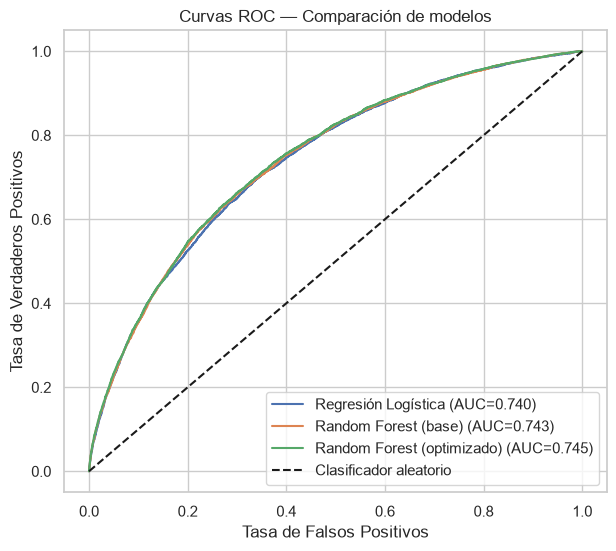

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, proba in [("Regresión Logística", y_proba_lr),
                       ("Random Forest (base)", y_proba_rf),
                       ("Random Forest (optimizado)", y_proba_best)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curvas ROC — Comparación de modelos")
ax.legend()
plt.show()


**Interpretación de resultados:** [completar tras ejecutar] — se espera que el Random Forest
optimizado supere a la Regresión Logística en ROC-AUC, dado que puede capturar interacciones no
lineales entre variables. El Recall de la clase minoritaria (incumplimiento) es la métrica de mayor
interés de negocio: un Recall bajo implica que el modelo deja pasar clientes riesgosos sin detectarlos,
lo cual es más costoso para la institución que un falso positivo (rechazar a un buen cliente).

## 7. Interpretación del Modelo y Conclusiones

### 7.1 Variables más importantes

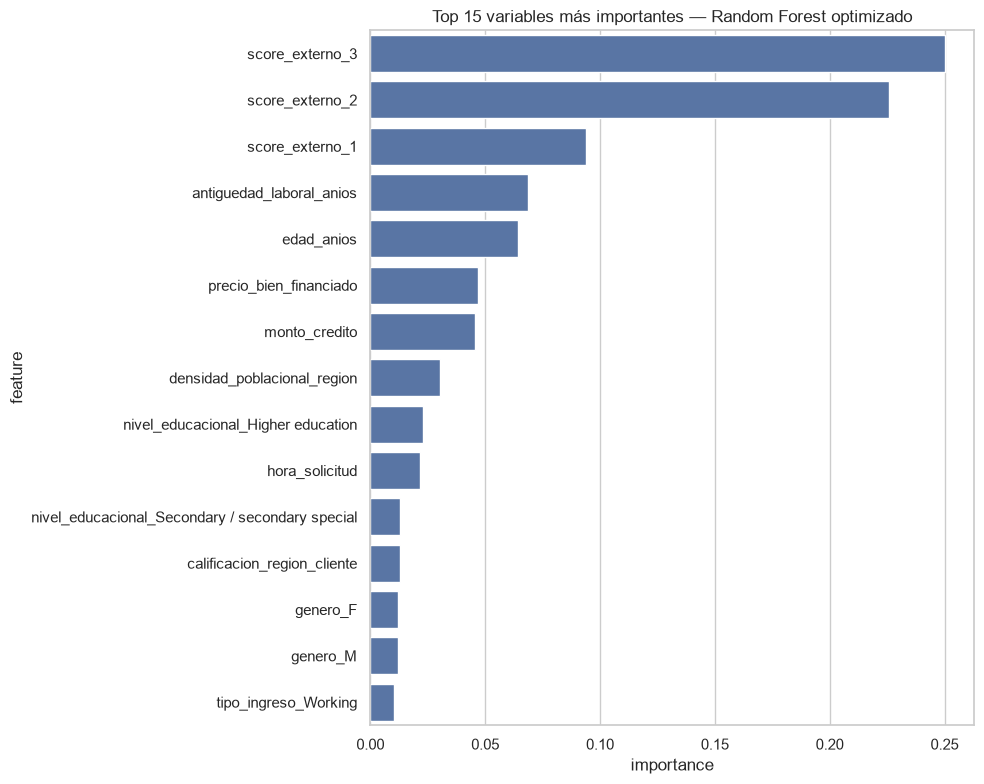

,feature,importance
6,score_externo_3,0.250305
5,score_externo_2,0.225792
4,score_externo_1,0.093907
12,antiguedad_laboral_anios,0.068817
11,edad_anios,0.064265
1,precio_bien_financiado,0.047018
0,monto_credito,0.045610
2,densidad_poblacional_region,0.030210
19,nivel_educacional_Higher education,0.022911
9,hora_solicitud,0.021689


In [31]:
importancias = pd.DataFrame({
    "feature": selected_features,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importancias.head(15), y="feature", x="importance")
plt.title("Top 15 variables más importantes — Random Forest optimizado")
plt.tight_layout()
plt.show()

importancias.head(15)


### 7.2 Fortalezas del modelo
- Buen desempeño en ROC-AUC, métrica robusta al desbalance de clases.
- Uso de `class_weight='balanced'` evita que el modelo ignore la clase minoritaria (incumplimiento).
- La curación previa por criterio de negocio (sección 1.5) hace que el modelo sea más fácil de explicar:
  cada variable final tiene un nombre y significado claro para un analista de riesgo.
- Feature importance coincide con la intuición de negocio (`score_externo_*`, edad, antigüedad laboral),
  lo que da confianza en que el modelo captura señal real y no ruido.

### 7.3 Limitaciones del modelo
- El dataset sigue desbalanceado (~92/8); incluso con `class_weight`, el Recall de la clase positiva
  tiene margen de mejora.
- Se descartó desde el inicio el bloque de variables de vivienda y varios flags administrativos, que
  podrían aportar algo de señal adicional aunque de menor relevancia de negocio.
- No se incorporaron las tablas satélite (`bureau.csv`, `previous_application.csv`, etc.), que en la
  competencia original de Kaggle son clave para mejorar sustancialmente el desempeño.
- El modelo no fue calibrado (las probabilidades predichas pueden no reflejar frecuencias reales).

### 7.4 Posibles mejoras
- Incorporar variables agregadas desde `bureau.csv` y `previous_application.csv` (historial crediticio
  externo y con Home Credit).
- Probar técnicas de resampling (SMOTE) en lugar de solo `class_weight`.
- Probar modelos de gradient boosting más avanzados (XGBoost, LightGBM).
- Calibrar las probabilidades del modelo (`CalibratedClassifierCV`) si se van a usar como score de
  riesgo directo.

### 7.5 Aplicación práctica en un contexto real
Este modelo podría integrarse como un **motor de scoring de pre-aprobación crediticia**: al recibir una
solicitud, el sistema calcula la probabilidad de incumplimiento y la usa para (a) aprobar automáticamente
solicitudes de muy bajo riesgo, (b) rechazar automáticamente las de muy alto riesgo, y (c) derivar los
casos intermedios a evaluación manual — optimizando el tiempo del equipo de riesgo y estandarizando el
criterio de decisión.


## 8. Exportación del modelo entrenado

In [32]:
joblib.dump(best_rf, "modelo_home_credit_rf.joblib")
joblib.dump(preprocessor, "preprocessor_home_credit.joblib")
joblib.dump(selector, "selector_home_credit.joblib")

print("Modelo y transformadores guardados correctamente.")


Modelo y transformadores guardados correctamente.
